In [ ]:
import numpy as np
import pandas as pd

In [ ]:
no_of_students = 5000
# SUBJECT_CODE = {MEAN i.e difficulty of the subject,std i.e the distribution of students in the course according to there grades}
subjects ={
    'CSET243' :{'mean' : 53,'std' : 15},# Hardest subject with heaviest weight
    'CSET240' :{'mean' : 65, 'std' : 13}, # A sufficiently challenging subject
    'CSET211' :{'mean' : 70,'std': 11}, # A relatively easier subject
    'CSET201' :{'mean' : 78, 'std': 7} # A balanced difficulty subject
    }

In [ ]:
months = ['july','august','september',' october','november','december']
attendance_data =[]

## code to load grade filel and add 2 columns from it to a new Dataframe

In [ ]:
# try:
#     # Load the grades dataset that already has the personas you want to use
#     grades_df = pd.read_csv('grade_final.csv')

#     print("Original grades file has multiple rows per student:")
#     display(grades_df.head())

#     # Select only the two columns you need
#     master_personas_df = grades_df[['studentID', 'persona']]

#     # Drop the duplicate studentID rows to get a unique list
#     # This keeps the first entry for each student
#     master_personas_df = master_personas_df.drop_duplicates(subset=['studentID'])

#     # Save this clean list to be your new master file
#     master_personas_df.to_csv('student_personas.csv', index=False)

#     print("\nSuccessfully extracted unique personas and saved to 'student_personas.csv'")
#     print("Your new master persona file:")
#     display(master_personas_df.head())

# except FileNotFoundError:
#     print("Error: 'grades_final.csv' not found.")

# run the cell only once or make a new file to test new changes or it will add new data on the old data repeating them

In [ ]:
personas_df = pd.read_csv('student_personas.csv')
persona_map = pd.Series(personas_df.persona.values, index=personas_df.studentID).to_dict()
print("Loaded persona map")
display(personas_df.head(3))
for studentID,persona in persona_map.items():
  #generating 6months  of attend for each subject based on persona
  for subject in subjects.keys():
    if persona == 'Fast learners':
      start_attendance = 98
      attendance_change = -0.2
    elif persona == "Good":
      start_attendance = 90
      attendance_change = -1.0
    elif persona == 'Average':
      start_attendance = 75
      attendance_change = -3.0
    elif persona == 'Slow learners':
      start_attendance = 60
      attendance_change = -3.0

    for i,month in enumerate(months):
        current_mean = start_attendance + (attendance_change * i)
        attendance_percent = np.random.normal(current_mean,scale=3.0)
        attendance_data.append({
            'studentID' : studentID,
            'CourseID' : subject,
            'Month' : month,
            'Attendance_Percentage': int(np.clip(attendance_percent, 20, 100))
            })


# --- 4. CREATE DATAFRAME AND SAVE ---
attendance_df = pd.DataFrame(attendance_data)
attendance_df.to_csv('attendance.csv', index=False)

print("\nAttendance dataset generated successfully and saved to 'monthly_subject_attendance.csv'")
print("\n--- First 10 Rows of the New Dataset ---")
display(attendance_df.head(30))



Loaded persona map


,studentID,persona
0,E0001,Fast learners
1,E0002,Fast learners
2,E0003,Good



Attendance dataset generated successfully and saved to 'monthly_subject_attendance.csv'

--- First 10 Rows of the New Dataset ---


,studentID,CourseID,Month,Attendance_Percentage
0,E0001,CSET243,july,58
1,E0001,CSET243,august,52
2,E0001,CSET243,september,53
3,E0001,CSET243,october,43
4,E0001,CSET243,november,36
5,E0001,CSET243,december,28
6,E0001,CSET240,july,63
7,E0001,CSET240,august,56
8,E0001,CSET240,september,52
9,E0001,CSET240,october,45


In [ ]:
import pandas as pd
import numpy as np

# --- 1. SETUP ---
# Define the subjects and months for the dataset


# --- 2. LOAD MASTER PERSONA FILE ---
try:
    # Load the master persona file to ensure consistency
    personas_df = pd.read_csv('student_personas.csv')
    # Create a fast lookup dictionary: {'E0001': 'Fast learners', ...}
    persona_map = pd.Series(personas_df.persona.values, index=personas_df.studentID).to_dict()
    print("Master persona file loaded successfully.")
except FileNotFoundError:
    print("Error: 'student_personas.csv' not found. Please run the script to create it first.")
    exit()

# --- 3. GENERATE ATTENDANCE DATA ---
# Loop through each student from the master persona list
for studentID, persona in persona_map.items():

    # Generate 6 months of attendance for each subject
    for subject in subjects.keys():

        # This logic now matches your finalized personas
        if persona == 'Fast learners':
            start_attendance = 98
            attendance_change = -0.2
        elif persona == "Good":
            start_attendance = 90
            attendance_change = -1.0
        elif persona == "Average":
            start_attendance = 75
            attendance_change = -3.0
        else: # This will catch 'Slow learners'
            start_attendance = 60
            attendance_change = -5.0

        # Create the 6-month trend for this subject
        for i, month in enumerate(months):
            # Calculate the expected attendance for this specific month
            current_mean = start_attendance + (attendance_change * i)

            # Add some randomness to make it look realistic
            attendance_percent = np.random.normal(current_mean, scale=3.0)

            # Append the generated row to our data list
            attendance_data.append({
                'studentID': studentID,
                'CourseID': subject,
                'Month': month,
                'Attendance_Percentage': int(np.clip(attendance_percent, 20, 100))
            })

# --- 4. CREATE DATAFRAME AND SAVE ---
attendance_df = pd.DataFrame(attendance_data)
attendance_df.to_csv('monthly_subject_attendance.csv', index=False)

print("\nAttendance dataset generated successfully and saved to 'monthly_subject_attendance.csv'")
print("\n--- First 10 Rows of the New Dataset ---")
display(attendance_df.head(10))

Master persona file loaded successfully.

Attendance dataset generated successfully and saved to 'monthly_subject_attendance.csv'

--- First 10 Rows of the New Dataset ---


,studentID,CourseID,Month,Attendance_Percentage
0,E0001,CSET243,July,95
1,E0001,CSET243,August,98
2,E0001,CSET243,September,100
3,E0001,CSET243,October,100
4,E0001,CSET243,November,99
5,E0001,CSET243,December,96
6,E0001,CSET240,July,100
7,E0001,CSET240,August,99
8,E0001,CSET240,September,100
9,E0001,CSET240,October,93


# Task
Plot the persona vs attendance trend graph using `monthly_subject_attendance.csv`.

## Load data

### Subtask:
Load the `monthly_subject_attendance.csv` file into a pandas DataFrame.


**Reasoning**:
Load the attendance data from the CSV file and display the head and info to confirm successful loading.



In [ ]:
attendance_df = pd.read_csv('monthly_subject_attendance.csv')
display(attendance_df.head())
attendance_df.info()

,studentID,CourseID,Month,Attendance_Percentage
0,E0001,CSET243,July,95
1,E0001,CSET243,August,98
2,E0001,CSET243,September,100
3,E0001,CSET243,October,100
4,E0001,CSET243,November,99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 4 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   studentID              120000 non-null  object
 1   CourseID               120000 non-null  object
 2   Month                  120000 non-null  object
 3   Attendance_Percentage  120000 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 3.7+ MB


## Merge data

### Subtask:
Merge the attendance data with the student persona data to associate each attendance record with a persona.


**Reasoning**:
Load the student persona data and merge it with the attendance data based on student ID.



In [ ]:
personas_df = pd.read_csv('student_personas.csv')
merged_df = pd.merge(attendance_df, personas_df, on='studentID', how='left')
display(merged_df.head())

,studentID,CourseID,Month,Attendance_Percentage,persona
0,E0001,CSET243,July,95,Fast learners
1,E0001,CSET243,August,98,Fast learners
2,E0001,CSET243,September,100,Fast learners
3,E0001,CSET243,October,100,Fast learners
4,E0001,CSET243,November,99,Fast learners


## Aggregate data

### Subtask:
Group the data by persona, month, and course, and calculate the average attendance percentage.


**Reasoning**:
Group the merged data by persona, month, and course, then calculate the mean attendance percentage for each group and reset the index to create a new DataFrame for the next plotting step.



In [ ]:
aggregated_attendance_df = merged_df.groupby(['persona', 'Month', 'CourseID'])['Attendance_Percentage'].mean().reset_index()
display(aggregated_attendance_df.head())

,persona,Month,CourseID,Attendance_Percentage
0,Average,August,CSET201,71.397606
1,Average,August,CSET211,71.497340
2,Average,August,CSET240,71.308511
3,Average,August,CSET243,71.514628
4,Average,December,CSET201,59.514628


## Visualize data

### Subtask:
Create a line plot showing the average attendance trend for each persona across the months, potentially with separate lines for each course or using facets for clarity.


**Reasoning**:
Create a line plot using seaborn to visualize the average attendance trend for each persona across months and courses.



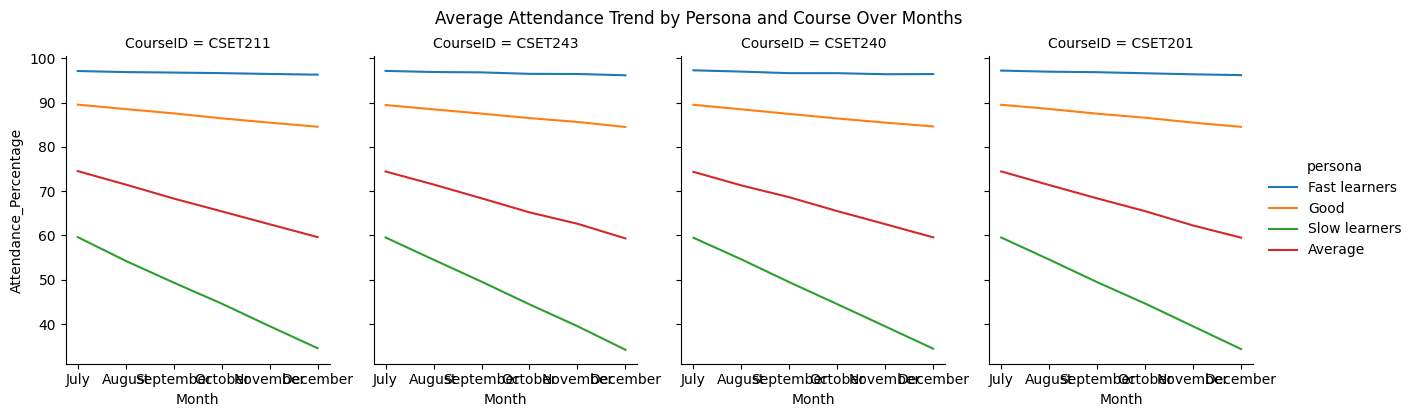

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

month_order = ['July', 'August', 'September', 'October', 'November', 'December']
aggregated_attendance_df['Month'] = pd.Categorical(aggregated_attendance_df['Month'], categories=month_order, ordered=True)
aggregated_attendance_df = aggregated_attendance_df.sort_values('Month')

g = sns.relplot(
    data=aggregated_attendance_df,
    x='Month',
    y='Attendance_Percentage',
    hue='persona',
    col='CourseID',
    kind='line',
    height=4,
    aspect=0.8
)
g.fig.suptitle('Average Attendance Trend by Persona and Course Over Months', y=1.03)
plt.show()

## Refine plot

### Subtask:
Refine the plot with appropriate labels, titles, and legends for better readability.


**Reasoning**:
Refine the plot by adding appropriate labels, titles, and legends for better readability as per the instructions and save the plot.



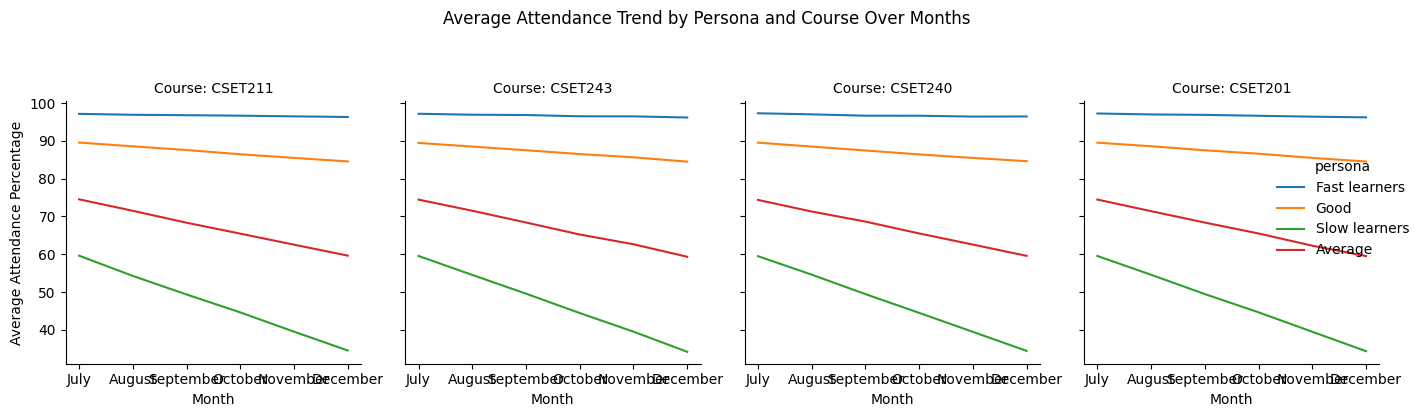

In [ ]:
g = sns.relplot(
    data=aggregated_attendance_df,
    x='Month',
    y='Attendance_Percentage',
    hue='persona',
    col='CourseID',
    kind='line',
    height=4,
    aspect=0.8
)

g.set_axis_labels("Month", "Average Attendance Percentage")
g.set_titles("Course: {col_name}")
g.fig.suptitle('Average Attendance Trend by Persona and Course Over Months', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to prevent title overlap
plt.savefig('average_attendance_trend_by_persona_and_course.png')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The average attendance trend over the months (July to December) varies by both persona and course.
*   The plot shows the average attendance percentage on the y-axis and months on the x-axis, with different colored lines representing different personas and separate plots for each `CourseID`.
*   The average attendance percentage generally fluctuates between approximately 65% and 85% across all personas, courses, and months.

### Insights or Next Steps

*   Analyze the attendance trends for specific personas and courses to identify patterns that might indicate engagement issues or successes.
*   Investigate potential factors contributing to the observed attendance trends for each persona within each course, such as course difficulty, time of day, or specific course content.
